In [1]:
import tensorflow as tf
import time
import numpy as np
import os
import copy
import pickle
import argparse
import utilityarm as utility
import pandas as pd
from sklearn.metrics import *
import tensorflow.keras.backend as K

In [2]:
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior() 


class FairAdvBPR:

    def __init__(self, sess, dict_args, train_df, test_df, user_type, type_error_weight, key_type, user_type_list, item_type_count, adv_const):
       
        self.dataname = dict_args['dataname']

        self.key_type = key_type
        self.user_type_list = user_type_list
        self.item_type_count = item_type_count
        self.layers = dict_args['layers']
        self.sess = sess
        
        self.num_cols = len(train_df['item_id'].unique())
        self.num_rows = len(train_df['user_id'].unique())

        self.hidden_neuron = dict_args['hidden_neuron']
        self.neg = dict_args['neg']
        self.batch_size = dict_args['batch_size']

        self.train_df = train_df
        self.vali_df = test_df
        self.num_train = len(self.train_df)
        self.num_vali = len(self.vali_df)
        self.adv_const = adv_const
        
        self.train_epoch = dict_args['train_epoch']
        self.train_epoch_a = dict_args['train_epoch_a']
       # self.train_epoch_a_post = dict_args['train_epoch_a_post']
        self.train_epoch_all = dict_args['train_epoch_all']

        self.lr_r = dict_args['lr_r'] # learning rate
        self.lr_a = dict_args['lr_a'] # learning rate
        self.alpha = dict_args['alpha'] # learning rate
        self.optimizer_method = dict_args['optimizer_method']
        self.display_step = dict_args['display_step']
        
        self.type_error_weight = type_error_weight
        self.num_type = dict_args['num_type']
        
        self.user_type = user_type
        self.type_count_list = []
        for k in range(self.num_type):
            self.type_count_list.append(np.sum(user_type[:,k]))

        
        self.reg = dict_args['reg'] # regularization term trade-off
        self.reg_s = dict_args['reg_s']

        print('**********fairAdvBPR**********')
        #print(self.args)
        self._prepare_model()

    def loadmodel(self, saver, checkpoint_dir):
        ckpt = tf.train.get_checkpoint_state(checkpoint_dir)
        if ckpt and ckpt.model_checkpoint_path:
            ckpt_name = os.path.basename(ckpt.model_checkpoint_path)
            saver.restore(self.sess, os.path.join(checkpoint_dir, ckpt_name))
            return True
        else:
            return False
        
    def run(self):
        init = tf.global_variables_initializer()
        self.sess.run(init)

        saver = tf.train.Saver([self.P, self.Q])
        self.loadmodel(saver, "./"+self.dataname+"/BPR_check_points")

        for epoch_itr in range(1, self.train_epoch + 1 + self.train_epoch_a+ self.train_epoch_all):
            self.train_model(epoch_itr)
            if epoch_itr % self.display_step == 0:
                self.test_model(epoch_itr)
        return self.make_records()

    def _prepare_model(self):
        with tf.name_scope("input_data"):
            self.user_input = tf.placeholder(tf.int32, shape=[None, 1], name="user_input")
            self.item_input_pos = tf.placeholder(tf.int32, shape=[None, 1], name="item_input_pos")
            self.item_input_neg = tf.placeholder(tf.int32, shape=[None, 1], name="item_input_neg")

            self.input_user_type = tf.placeholder(dtype=tf.float32, shape=[None, self.num_type]
                                                   , name="input_user_type")
            self.input_user_error_weight = tf.placeholder(dtype=tf.float32, shape=[None, 1]
                                                          , name="input_user_error_weight")

        with tf.variable_scope("BPR", reuse=tf.AUTO_REUSE):
            self.P = tf.get_variable(name="P",
                                     initializer=tf.truncated_normal(shape=[self.num_rows, self.hidden_neuron], mean=0,
                                                                     stddev=0.03), dtype=tf.float32)
            self.Q = tf.get_variable(name="Q",
                                     initializer=tf.truncated_normal(shape=[self.num_cols+1, self.hidden_neuron], mean=0,
                                                                     stddev=0.03), dtype=tf.float32)
        para_r = tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES, scope="BPR")

        with tf.variable_scope("Adversarial", reuse=tf.AUTO_REUSE):
            num_layer = len(self.layers)
            adv_W = []
            adv_b = []
            for l in range(num_layer):
                if l == 0:
                    in_shape = 21
                else:
                    in_shape = self.layers[l - 1]
                adv_W.append(tf.get_variable(name="adv_W" + str(l),
                                             initializer=tf.truncated_normal(shape=[in_shape, self.layers[l]],
                                                                             mean=0, stddev=0.03), dtype=tf.float32))
                adv_b.append(tf.get_variable(name="adv_b" + str(l),
                                             initializer=tf.truncated_normal(shape=[1, self.layers[l]],
                                                                             mean=0, stddev=0.03), dtype=tf.float32))
            adv_W_out = tf.get_variable(name="adv_W_out",
                                        initializer=tf.truncated_normal(shape=[self.layers[-1], self.num_type],
                                                                        mean=0, stddev=0.03), dtype=tf.float32)

            adv_b_out = tf.get_variable(name="adv_b_out",
                                        initializer=tf.truncated_normal(shape=[1, self.num_type],
                                                                        mean=0, stddev=0.03), dtype=tf.float32)
        para_a = tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES, scope="Adversarial")

        p = tf.reduce_sum(tf.nn.embedding_lookup(self.P, self.user_input), 1)
        q_neg = tf.reduce_sum(tf.nn.embedding_lookup(self.Q, self.item_input_neg), 1)
        q_pos = tf.reduce_sum(tf.nn.embedding_lookup(self.Q, self.item_input_pos), 1)

        predict_pos = tf.reduce_sum(p * q_pos, 1)
        predict_neg = tf.reduce_sum(p * q_neg, 1)

        r_cost1 = tf.reduce_sum(tf.nn.softplus(-(predict_pos - predict_neg)))
        r_cost2 = self.reg * 0.5 * (self.l2_norm(self.P) + self.l2_norm(self.Q))  # regularization term
#         pred = tf.matmul(self.P, tf.transpose(self.Q))
#         self.s_mean = tf.reduce_mean(pred, axis=1)
#         self.s_std = tf.keras.backend.std(pred, axis=1)
#         self.s_cost = tf.reduce_sum(tf.square(self.s_mean) + tf.square(self.s_std) - 2 * tf.log(self.s_std) - 1)#additional regularization
        self.s_mean = 0
        self.s_std = 0
        self.s_cost = 0
        
#        print('input_user_type ',self.input_user_type[:,1].shape)
#         usertype = self.input_user_type[]
#         print('shape',usertype.shape)
#         const_user_type1 = tf.reduce_sum(tf.nn.softplus(-(predict_pos - predict_neg) * self.input_user_type[:,0]))
#         const_user_type2 = tf.reduce_sum(tf.nn.softplus(-(predict_pos - predict_neg) * self.input_user_type[:,1]))
        
#        const = K.sqrt(K.square(const_user_type1 - const_user_type2))
        
#        self.r_cost = r_cost1 + r_cost2 + 1 * const + self.reg_s * 0.5 * self.s_cost
        self.r_cost = r_cost1 + r_cost2 
        
        print('shape q pos',q_pos.shape)
        print('shape p',p.shape)
        print('shape predict pos ', predict_pos.shape)
        
        adv_last = tf.reshape(predict_pos, [tf.shape(self.input_user_type)[0], 1])
        print('shape adv_last ', adv_last.shape)
        adv_last = tf.concat([adv_last, q_pos], 1)
        
        for l in range(num_layer):
            adv = tf.nn.relu(tf.matmul(adv_last, adv_W[l]) + adv_b[l])
            adv_last = adv
        self.adv_output = tf.nn.sigmoid(tf.matmul(adv_last, adv_W_out) + adv_b_out)
 #       self.a_cost = tf.reduce_sum(tf.square(self.adv_output - self.input_user_type) * self.input_user_error_weight)
        self.a_cost = tf.reduce_sum(- self.input_user_type * tf.math.log(self.adv_output))

    
                  

 #       self.all_cost = self.r_cost - self.alpha * self.a_cost  # the loss function
        self.all_cost = self.r_cost - self.adv_const * self.a_cost  # the loss function

        with tf.variable_scope("Optimizer", reuse=tf.AUTO_REUSE):
            self.r_optimizer = tf.train.AdamOptimizer(learning_rate=self.lr_r).minimize(self.r_cost, var_list=para_r)
            self.a_optimizer = tf.train.AdamOptimizer(learning_rate=self.lr_a).minimize(self.a_cost, var_list=para_a)
            self.all_optimizer = tf.train.AdamOptimizer(learning_rate=self.lr_r).minimize(self.all_cost, var_list=para_r)


    def train_model(self, itr):
        NS_start_time = time.time() * 1000.0
        epoch_r_cost = 0.0
        epoch_s_cost = 0.0
        epoch_s_mean = 0.0
        epoch_s_std = 0.0
        epoch_a_cost = 0.0
        accuracy_adv_pre_temp = 0.0
        accuracy_adv_post_temp = 0.0
        accuracy_adv_pre =[]
        accuracy_adv_post =[]
        self.accuracy_adv_pre = [0]
        epoch_adv_acc_pre = 0.0
        epoch_adv_acc_post = 0.0
        num_sample, user_list, item_pos_list, item_neg_list = utility.negative_sample(self.train_df, self.num_rows,
                                                                                      self.num_cols, self.neg)
        NS_end_time = time.time() * 1000.0

        start_time = time.time() * 1000.0
        num_batch = int(num_sample / float(self.batch_size)) + 1
        random_idx = np.random.permutation(num_sample)
        for i in range(num_batch):
            # get the indices of the current batch
            if i == num_batch - 1:
                batch_idx = random_idx[i * self.batch_size:]
            elif i < num_batch - 1:
                batch_idx = random_idx[(i * self.batch_size):((i + 1) * self.batch_size)]
            
            accuracy_adv_pre_temp = 0.0
            accuracy_adv_post_temp = 0.0
            # training of adversary
            if itr > self.train_epoch and itr < (self.train_epoch + self.train_epoch_a + 1):
                #random_idx_a = np.random.permutation(num_sample)
                #print("boucle adversarial debut-- num batch ",i)
                #for j in range(num_batch):
#                 if j == num_batch - 1:
#                 batch_idx_a = random_idx_a[j * self.batch_size:]
#                 elif j < num_batch - 1:
#                 batch_idx_a = random_idx_a[(j * self.batch_size):((j + 1) * self.batch_size)]
                user_idx_list = ((user_list[batch_idx, :]).reshape((len(batch_idx)))).tolist()
                _, tmp_a_cost, adv_output = self.sess.run(  # do the optimization by the minibatch
                        [self.a_optimizer, self.a_cost, self.adv_output],
                feed_dict={self.user_input: user_list[batch_idx, :],
                                   self.item_input_pos: item_pos_list[batch_idx, :],
                                   self.item_input_neg: item_neg_list[batch_idx, :],
                                   self.input_user_type: self.user_type[user_idx_list,:],
                                   self.input_user_error_weight: self.type_error_weight[user_idx_list,:]})
                epoch_a_cost += tmp_a_cost
                    
                g = tf.Graph()
                with g.as_default():
                    logits = adv_output
                      
                    labels = self.user_type[user_idx_list,:]
                      
                    acc, acc_op = tf.compat.v1.metrics.accuracy(labels, logits)
                    global_init = tf.compat.v1.global_variables_initializer()
                    local_init = tf.compat.v1.local_variables_initializer()
                sess = tf.compat.v1.Session(graph=g)
                sess.run([global_init, local_init])
                acc, acc_op = sess.run([acc, acc_op])
                    #print('post adversarial -- adversaire ready ',acc_op)
                accuracy_adv_pre_temp += acc_op
                sess.close()
                accuracy_adv_pre.append(accuracy_adv_pre_temp)
                print('post adversarial -- adversaire ready after one adv epoch training ',accuracy_adv_pre_temp)
                
                if itr == self.train_epoch + self.train_epoch_a:
                    self.accuracy_adv_pre.append(accuracy_adv_pre_temp)
                
            if itr > (self.train_epoch + self.train_epoch_a ):  
                
                user_idx_list = ((user_list[batch_idx, :]).reshape((len(batch_idx)))).tolist()
                _, tmp_r_cost = self.sess.run(  # do the optimization by the minibatch
                    [self.all_optimizer, self.all_cost],
                    feed_dict={self.user_input: user_list[batch_idx, :],
                               self.item_input_pos: item_pos_list[batch_idx, :],
                               self.item_input_neg: item_neg_list[batch_idx, :],
                               self.input_user_type: self.user_type[user_idx_list, :],
                               self.input_user_error_weight: self.type_error_weight[user_idx_list, :]})
                epoch_r_cost += tmp_r_cost
                #mesure perf adv post training of main model
#                 for j in range(num_batch):
#                     if j == num_batch - 1:
#                         batch_idx_a = random_idx_a[j * self.batch_size:]
#                     elif j < num_batch - 1:
#                         batch_idx_a = random_idx_a[(j * self.batch_size):((j + 1) * self.batch_size)]
            
             
                user_idx_list = ((user_list[batch_idx, :]).reshape((len(batch_idx)))).tolist()
#                 _,tmp_a_cost, adv_output_post = self.sess.run(  # do the optimization by the minibatch
#                          [self.a_optimizer, self.a_cost, self.adv_output], feed_dict={self.user_input: user_list[batch_idx, :],
#                                     self.item_input_pos: item_pos_list[batch_idx, :],
#                                     self.item_input_neg: item_neg_list[batch_idx, :],
#                                     self.input_user_type: self.user_type[user_idx_list,:],
#                                     self.input_user_error_weight: self.type_error_weight[user_idx_list,:]})
#                 epoch_a_cost += tmp_a_cost
                
                adv_output_post = self.sess.run(  # do the optimization by the minibatch
                        [ self.adv_output],
                feed_dict={self.user_input: user_list[batch_idx, :],
                                   self.item_input_pos: item_pos_list[batch_idx, :],
                                   self.item_input_neg: item_neg_list[batch_idx, :],
                                   self.input_user_type: self.user_type[user_idx_list,:],
                                   self.input_user_error_weight: self.type_error_weight[user_idx_list,:]})
                    
                g = tf.Graph()
                with g.as_default():
                    labels2 = self.user_type[user_idx_list,:] 
                    logits2 = adv_output_post                    
                    acc, acc_op = tf.compat.v1.metrics.accuracy(labels2, logits2[0])
                    global_init = tf.compat.v1.global_variables_initializer()
                    local_init = tf.compat.v1.local_variables_initializer()
                sess = tf.compat.v1.Session(graph=g)
                sess.run([global_init, local_init])
                acc, acc_op = sess.run([acc, acc_op])
                    #print('post main model training -- adversaire dejoue', acc_op)
                accuracy_adv_post_temp += acc_op
                sess.close()
                accuracy_adv_post.append(accuracy_adv_post_temp)
                print('post adversarial -- adversaire dejoue after one re-training of main model ',accuracy_adv_post_temp)
                
                
                print("boucle adversarial fin")
            else:
                user_idx_list = ((user_list[batch_idx, :]).reshape((len(batch_idx)))).tolist()
                _, tmp_r_cost = self.sess.run(  # do the optimization by the minibatch
                    [self.r_optimizer, self.r_cost],
                    feed_dict={self.user_input: user_list[batch_idx, :],
                               self.item_input_pos: item_pos_list[batch_idx, :],
                               self.item_input_neg: item_neg_list[batch_idx, :],
                               self.input_user_type: self.user_type[user_idx_list, :],
                               self.input_user_error_weight: self.type_error_weight[user_idx_list, :]})
                epoch_r_cost += tmp_r_cost
    
        epoch_a_cost /= num_batch
        epoch_adv_acc_pre = sum(accuracy_adv_pre)/num_batch
        epoch_adv_acc_post = sum(accuracy_adv_post)/num_batch
        epoch_adv_acc_pre_lastAdvIter = sum(self.accuracy_adv_pre)/num_batch
        
        
        filename = './const_IembfairAdvBPRresultsAdvConst'+str(self.adv_const)+ '/epoch'+ str(itr) +'_pre_' + self.dataname + '_accAdvpre.npy'
        os.makedirs(os.path.dirname(filename), exist_ok=True)           
        with open(filename, "wb") as f:
                np.save(f, epoch_adv_acc_pre) 
        filename1 = './const_IembfairAdvBPRresultsAdvConst'+str(self.adv_const)+ '/epoch'+ str(itr) +'_post_' + self.dataname + '_accAdvpost.npy'
        os.makedirs(os.path.dirname(filename1), exist_ok=True)           
        with open(filename1, "wb") as f:
                np.save(f, epoch_adv_acc_post) 
                
        if itr % self.display_step == 0:
            print ("Training //", "Epoch %d //" % itr, " Total r_cost = %.5f" % epoch_r_cost,
                   " Total a_cost = %.5f" % epoch_a_cost,
                   "total pre adversarial accuracy = %.5f" % epoch_adv_acc_pre,
                   "total pre adversarial accuracy = %.5f" % epoch_adv_acc_pre_lastAdvIter,
                   "total post adversarial accuracy = %.5f" % epoch_adv_acc_post,
                   "Training time : %d ms" % (time.time() * 1000.0 - start_time),
                   "negative Sampling time : %d ms" % (NS_end_time - NS_start_time),
                   "negative samples : %d" % (num_sample))
       
    def test_model(self, itr):  # calculate the cost and rmse of testing set in each epoch
        if itr % self.display_step == 0:
            start_time = time.time() * 1000.0
            P, Q = self.sess.run([self.P, self.Q])
            Rec = np.matmul(P, Q.T)

            [precision, recall, f_score, NDCG] = utility.test_model_all(Rec, self.vali_df, self.train_df)
#             utility.ranking_analysis(Rec, self.vali_df, self.train_df, self.key_genre, self.item_genre_list,
#                                      self.user_genre_count)
            utility.test_model_per_user_type(Rec, self.vali_df, self.train_df, self.user_type_list, self.key_type)
            auc = utility.auc_per_user(Rec, self.vali_df, self.train_df)
            print("AUC global is: ", auc)
            
            filename = './const_IembfairAdvBPRresultsAdvConst'+str(self.adv_const)+ '/epoch'+ str(itr) +'_Rec_' + self.dataname + '_constfairAdvBPR.npy'
            os.makedirs(os.path.dirname(filename), exist_ok=True)           
            with open(filename, "wb") as f:
                np.save(f, Rec)
                

            

    def make_records(self):  # record all the results' details into files
        P, Q = self.sess.run([self.P, self.Q])
        Rec = np.matmul(P, Q.T)

        [precision, recall, f_score, NDCG] = utility.test_model_all(Rec, self.vali_df, self.train_df)
        return precision, recall, f_score, NDCG, Rec

#     def test_model(self, itr):  # calculate the cost and rmse of testing set in each epoch
#         if itr % self.display_step == 0:
#             start_time = time.time() * 1000.0
#             P, Q = self.sess.run([self.P, self.Q])
#             Rec = np.matmul(P, Q.T)

#             [precision, recall, f_score, NDCG] = utility.test_model_all(Rec, self.vali_df, self.train_df)
# #             utility.ranking_analysis(Rec, self.vali_df, self.train_df, self.key_type, self.user_type_list,
# #                                      self.item_type_count)
#             utility.test_model_per_user_type(Rec, self.vali_df, self.train_df, self.user_type_list, self.key_type)
#             auc = utility.auc_per_user(Rec, self.vali_df, self.train_df)
#             print("AUC global is: ", auc)
#             print (
#                 "Testing //", "Epoch %d //" % itr,
#                 "Testing time : %d ms" % (time.time() * 1000.0 - start_time))
#             print("=" * 200)


    @staticmethod
    def l2_norm(tensor):
        return tf.reduce_sum(tf.square(tensor))


Instructions for updating:
non-resource variables are not supported in the long term


In [3]:

#optimizer_method = ['Adam', 'Adadelta', 'Adagrad', 'RMSProp', 'GradientDescent','Momentum'], default='Adam')


train_epoch = 10
train_epoch_a = 10 #default 20
train_epoch_all = 20
#train_epoch_a_post = 5
display_step = 1
lr_r = 0.01
lr_a = 0.005
reg = 0.1
reg_s = 30
alpha = 1000
optimizer_method = 'Adam'
hidden_neuron = 20
adv_const = [200, 100]
#adv_const = [5000]
neg = 5
batch_size = 1024
#layers = [50, 50, 50, 50]
layers = [64]
dataname = 'ml1m-6'

In [4]:
dict_args =  {"train_epoch": train_epoch,
              "train_epoch_a": train_epoch_a,
              "train_epoch_all": train_epoch_all,
             # "train_epoch_a_post": train_epoch_a_post,
            "display_step":display_step,
            "lr_r":lr_r,
            "lr_a":lr_a,
            "reg":reg,
            "reg_s":reg_s,
            "alpha":alpha,
            "optimizer_method":optimizer_method,
            "hidden_neuron":hidden_neuron,
            "adv_const":adv_const,
            "neg":neg,
            "batch_size":batch_size,
            "layers":layers,
            "dataname":dataname}
dict_args

{'train_epoch': 10,
 'train_epoch_a': 10,
 'train_epoch_all': 20,
 'display_step': 1,
 'lr_r': 0.01,
 'lr_a': 0.005,
 'reg': 0.1,
 'reg_s': 30,
 'alpha': 1000,
 'optimizer_method': 'Adam',
 'hidden_neuron': 20,
 'adv_const': [200, 100],
 'neg': 5,
 'batch_size': 1024,
 'layers': [64],
 'dataname': 'ml1m-6'}

In [5]:
with open('./training_df.pkl', 'rb') as f:
    train_df = pickle.load(f,encoding='latin1')

# with open('./' + dataname + '/valiing_df.pkl', 'rb') as f:
#     vali_df = pickle.load(f,encoding='latin1')  # for validation
    
with open('./testing_df.pkl', 'rb') as f:
    test_df = pickle.load(f,encoding='latin1')  # for validation
# vali_df = pickle.load(open('./' + dataname + '/testing_df.pkl'))  # for testing

with open('./key_type.pkl', 'rb') as f:
    key_type = pickle.load(f,encoding='latin1')
    
with open('./user_idd_type_list.pkl', 'rb') as f:
    user_idd_type_list = pickle.load(f,encoding='latin1')
    
with open('./type_user_vector.pkl', 'rb') as f:
    type_user_vector = pickle.load(f,encoding='latin1')

with open('./type_count.pkl', 'rb') as f:
    type_count = pickle.load(f,encoding='latin1')
    
with open('./item_type_count.pkl', 'rb') as f:
    item_type_count = pickle.load(f,encoding='latin1')

In [6]:
train_df.head(20)

,user_id,item_id,rating
0,1,1,3
1,2,2,1
2,3,3,2
3,4,4,1
4,6,6,2
5,7,7,5
6,8,8,3
7,9,9,3
8,10,10,2
9,11,11,5


In [7]:
train_df.shape

(80146, 3)

In [8]:
test_df.head(20)

,user_id,item_id,rating
0,0,0,3
1,5,5,4
2,12,12,5
3,13,13,3
4,17,17,2
5,20,20,4
6,24,25,2
7,30,31,4
8,35,35,1
9,40,40,4


In [9]:
test_df.shape

(19577, 3)

In [10]:
print(len(user_idd_type_list))

943


In [11]:
user_idd_type_list

[['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['M'],
 ['M'],
 ['M'],
 ['F'],
 ['F'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],
 ['M'],
 ['F'],
 ['M'],


In [12]:
print(type_user_vector['F'].shape)

(1, 943)


In [13]:
type_user_vector

{'M': array([[1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1.,
         0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0.,
         0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
         1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1.,
         0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
         1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
         1., 0., 1., 1., 1., 1., 1., 1., 0., 1

In [14]:
len(item_type_count)

1473

In [15]:
item_type_count

[{'M': 605, 'F': 247},
 {'M': 500, 'F': 206},
 {'M': 666, 'F': 270},
 {'M': 630, 'F': 249},
 {'M': 592, 'F': 257},
 {'M': 531, 'F': 251},
 {'M': 523, 'F': 240},
 {'M': 623, 'F': 251},
 {'M': 572, 'F': 231},
 {'M': 585, 'F': 232},
 {'M': 492, 'F': 212},
 {'M': 618, 'F': 248},
 {'M': 429, 'F': 217},
 {'M': 640, 'F': 261},
 {'M': 604, 'F': 256},
 {'M': 655, 'F': 254},
 {'M': 643, 'F': 247},
 {'M': 567, 'F': 220},
 {'M': 656, 'F': 267},
 {'M': 663, 'F': 271},
 {'M': 635, 'F': 254},
 {'M': 638, 'F': 252},
 {'M': 509, 'F': 236},
 {'M': 493, 'F': 204},
 {'M': 404, 'F': 177},
 {'M': 520, 'F': 231},
 {'M': 537, 'F': 226},
 {'M': 636, 'F': 260},
 {'M': 630, 'F': 250},
 {'M': 494, 'F': 221},
 {'M': 595, 'F': 249},
 {'M': 442, 'F': 201},
 {'M': 570, 'F': 244},
 {'M': 554, 'F': 212},
 {'M': 524, 'F': 227},
 {'M': 665, 'F': 272},
 {'M': 551, 'F': 232},
 {'M': 648, 'F': 262},
 {'M': 617, 'F': 260},
 {'M': 645, 'F': 266},
 {'M': 590, 'F': 231},
 {'M': 647, 'F': 270},
 {'M': 653, 'F': 270},
 {'M': 567,

In [16]:
print(type_count)

{'M': 670, 'F': 273}


In [17]:
num_item = len(train_df['item_id'].unique())
num_user = len(train_df['user_id'].unique())
num_type = len(key_type)
print('items number : ',num_item)
print('users number : ',num_user)
print('user types : ',key_type)


items number :  1472
users number :  943
user types :  ['M', 'F']


In [18]:
dict_args["num_type"] = len(key_type)

In [19]:
user_type_list = [] #preprocessing to be sure that user types are really the right ones armielle 
for u in range(num_user):
    gl = user_idd_type_list[u]
    tmp = []
    for g in gl:
        if g in key_type:
            tmp.append(g)
    user_type_list.append(tmp)

print(len(user_type_list))

943


In [20]:
# genreate user_type matrix
user_type = np.zeros((num_user, num_type))
for u in range(num_user):
    gl = user_type_list[u]
    for k in range(num_type):
        if key_type[k] in gl:
            user_type[u, k] = 1.0

In [21]:
len(user_type_list)

943

In [22]:
print('*' * 50)
print('number of positive feedback: ' + str(len(train_df)))
print('estimated number of training samples: ' + str(neg * len(train_df)))
print('*' * 50)

**************************************************
number of positive feedback: 80146
estimated number of training samples: 400730
**************************************************


In [23]:
type_count_mean_reciprocal = []
for k in key_type:
    type_count_mean_reciprocal.append(1.0 / type_count[k])
type_count_mean_reciprocal = (np.array(type_count_mean_reciprocal)).reshape((num_type, 1))
type_error_weight = np.dot(user_type, type_count_mean_reciprocal)


In [24]:
# generate user_type matrix
type_user_indicator = np.zeros((num_type, num_user))

for k in range(num_type):
    type_user_indicator[k,:] = type_user_vector[key_type[k]]


In [25]:
precision = np.zeros(4)
recall = np.zeros(4)
f1 = np.zeros(4)
ndcg = np.zeros(4)
RSP = np.zeros(4)
REO = np.zeros(4)

precision 

array([0., 0., 0., 0.])

In [26]:
len(user_type)

943

In [27]:
user_type.shape

(943, 2)

In [28]:
#tf.compat.v1.disable_eager_execution()
#tf.enable_eager_execution()
for i in adv_const:
    with tf.compat.v1.Session() as sess:
        fairadvbpr = FairAdvBPR(sess, dict_args, train_df, test_df, user_type, type_error_weight, key_type, user_type_list, item_type_count, i)
        [prec_one, rec_one, f_one, ndcg_one, Rec] = fairadvbpr.run()
        #[RSP_one, REO_one] = utility.ranking_analysis(Rec, vali_df, train_df, key_genre, item_genre_list, user_genre_count)
#         precision += prec_one
#         recall += rec_one
#         f1 += f_one
#         ndcg += ndcg_one
#         RSP += RSP_one
#         REO += REO_one

**********fairAdvBPR**********
shape q pos (?, 20)
shape p (?, 20)
shape predict pos  (?,)
shape adv_last  (?, 1)
INFO:tensorflow:Restoring parameters from ./ml1m-6/BPR_check_points\check_point.ckpt-41
Training // Epoch 1 //  Total r_cost = 196801.83823  Total a_cost = 0.00000 total pre adversarial accuracy = 0.00000 total pre adversarial accuracy = 0.00000 total post adversarial accuracy = 0.00000 Training time : 379 ms negative Sampling time : 8411 ms negative samples : 400730
precision_1	[0.4050901],	||	 precision_5	[0.3155885],	||	 precision_10	[0.2671262],	||	 precision_15	[0.2388830]
recall_1   	[0.0274844],	||	 recall_5   	[0.1045685],	||	 recall_10   	[0.1716990],	||	 recall_15   	[0.2232412]
f_measure_1	[0.0514763],	||	 f_measure_5	[0.1570871],	||	 f_measure_10	[0.2090367],	||	 f_measure_15	[0.2307974]
ndcg_1     	[0.4050901],	||	 ndcg_5     	[0.3372845],	||	 ndcg_10     	[0.3196129],	||	 ndcg_15     	[0.3176369]
Metrics for user type	 M
precision_1	[0.4223881],	||	 precision_

Metrics for user type	 M
precision_1	[0.4925373],	||	 precision_5	[0.3767164],	||	 precision_10	[0.3176119],	||	 precision_15	[0.2823881]
recall_1	[0.0355843],	||	 recall_5	[0.1209400],	||	 recall_10	[0.1942627],	||	 recall_15	[0.2492936]
ndcg_1	[0.4925373],	||	 ndcg_5	[0.4030580],	||	 ndcg_10	[0.3790916],	||	 ndcg_15	[0.3731250]
AUC per user type	[0.9106011]
Metrics for user type	 F
precision_1	[0.4615385],	||	 precision_5	[0.2937729],	||	 precision_10	[0.2498168],	||	 precision_15	[0.2170940]
recall_1	[0.0387037],	||	 recall_5	[0.1164204],	||	 recall_10	[0.1867540],	||	 recall_15	[0.2328605]
ndcg_1	[0.4615385],	||	 ndcg_5	[0.3286225],	||	 ndcg_10	[0.3174303],	||	 ndcg_15	[0.3148224]
AUC per user type	[0.9082786]
AUC global is:  0.9099287378435595
Training // Epoch 7 //  Total r_cost = 189067.06485  Total a_cost = 0.00000 total pre adversarial accuracy = 0.00000 total pre adversarial accuracy = 0.00000 total post adversarial accuracy = 0.00000 Training time : 345 ms negative Sampling 

post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post adversarial -- adversaire ready after one adv epoch training  0.0
post a

post adversarial -- adversaire ready after one adv epoch training  0.00146484375
post adversarial -- adversaire ready after one adv epoch training  0.0009765625
post adversarial -- adversaire ready after one adv epoch training  0.00341796875
post adversarial -- adversaire ready after one adv epoch training  0.001953125
post adversarial -- adversaire ready after one adv epoch training  0.00390625
post adversarial -- adversaire ready after one adv epoch training  0.00390625
post adversarial -- adversaire ready after one adv epoch training  0.00390625
post adversarial -- adversaire ready after one adv epoch training  0.0029296875
post adversarial -- adversaire ready after one adv epoch training  0.00390625
post adversarial -- adversaire ready after one adv epoch training  0.001953125
post adversarial -- adversaire ready after one adv epoch training  0.0048828125
post adversarial -- adversaire ready after one adv epoch training  0.0009765625
post adversarial -- adversaire ready after one a

post adversarial -- adversaire ready after one adv epoch training  0.0107421875
post adversarial -- adversaire ready after one adv epoch training  0.00830078125
post adversarial -- adversaire ready after one adv epoch training  0.01025390625
post adversarial -- adversaire ready after one adv epoch training  0.01171875
post adversarial -- adversaire ready after one adv epoch training  0.0107421875
post adversarial -- adversaire ready after one adv epoch training  0.015625
post adversarial -- adversaire ready after one adv epoch training  0.0107421875
post adversarial -- adversaire ready after one adv epoch training  0.01318359375
post adversarial -- adversaire ready after one adv epoch training  0.01416015625
post adversarial -- adversaire ready after one adv epoch training  0.01806640625
post adversarial -- adversaire ready after one adv epoch training  0.01220703125
post adversarial -- adversaire ready after one adv epoch training  0.00830078125
post adversarial -- adversaire ready af

...

post adversarial -- adversaire dejoue after one re-training of main model  0.23681640625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24267578125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24755859375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24267578125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23583984375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23876953125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23095703125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2548828125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23876953125
boucle adversari

post adversarial -- adversaire dejoue after one re-training of main model  0.22802734375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24365234375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.240234375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2275390625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2421875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.25341796875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2529296875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2431640625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23681640625
boucle adversarial fin
p

post adversarial -- adversaire dejoue after one re-training of main model  0.248046875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2412109375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24658203125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.25146484375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2548828125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23193359375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2392578125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.22998046875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23583984375
boucle adversarial f

post adversarial -- adversaire dejoue after one re-training of main model  0.25390625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23095703125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.25146484375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.25927734375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23828125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23876953125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.24609375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23974609375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2392578125
boucle adversarial fin
po

post adversarial -- adversaire dejoue after one re-training of main model  0.2509765625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23046875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.2509765625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23828125
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.244140625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.22998046875
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23193359375
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23681640625
boucle adversarial fin
post adversarial -- adversaire dejoue after one re-training of main model  0.23486328125
boucle adversarial fin
po

In [53]:
list_recom_unfairbpr = []
list_recom_constiemfairadvbpr100 = []
list_recom_constiemfairadvbpr200 = []
list_recom_constiemfairadvbpr400 = []
list_recom_constiemfairadvbpr600 = []
list_recom_constiemfairadvbpr800 = []
list_recom_constiemfairadvbpr1000 = []
list_recom_constiemfairadvbpr1200 = []
list_recom_constiemfairadvbpr1500 = []
list_recom_constiemfairadvbpr2000 = []
list_recom_constiemfairadvbpr2500 = []
list_recom_constiemfairadvbpr5000 = []

list_recom_fairadvbpr = []

list_recom_iemfairadvbpr = []
list_recom_uemfairbpr = []

list_acc_AdvPre100 = []
list_acc_AdvPost100 = []

list_acc_AdvPre200 = []
list_acc_AdvPost200 = []

list_acc_AdvPre400 = []
list_acc_AdvPost400 = []

list_acc_AdvPre600 = []
list_acc_AdvPost600 = []

list_acc_AdvPre800 = []
list_acc_AdvPost800 = []

list_acc_AdvPre1000 = []
list_acc_AdvPost1000 = []

list_acc_AdvPre1200 = []
list_acc_AdvPost1200 = []

list_acc_AdvPre1500 = []
list_acc_AdvPost1500 = []

list_acc_AdvPre2000 = []
list_acc_AdvPost2000 = []

list_acc_AdvPre2500 = []
list_acc_AdvPost2500 = []

list_acc_AdvPre5000 = []
list_acc_AdvPost5000 = []



for itr in range(1, 41 + 1):
    filename = './unfairBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_BPR.npy'
    with open(filename, "rb") as f:
        recom = np.load(f)
        list_recom_unfairbpr.append(recom)

for itr in range(1, 21 + 1):
    filename2 = './fairAdvBPR_results/epoch'+ str(itr) +'_Rec_' + dataname + '_fairAdvBPR.npy'
    with open(filename2, "rb") as f:
        recom = np.load(f)
        list_recom_fairadvbpr.append(recom)
adv_const = [200,600,1000,2000,2500]        
for j in adv_const:
    for itr in range(1, 30 + 1):
        filename = './const_IembfairAdvBPRresultsAdvConst'+ str(j) + '/epoch'+ str(itr) +'_pre_' + dataname + '_accAdvpre.npy'
        filename2 = './const_IembfairAdvBPRresultsAdvConst'+ str(j) + '/epoch'+ str(itr) +'_post_' + dataname + '_accAdvpost.npy'
        filename3 = './const_IembfairAdvBPRresultsAdvConst'+ str(j) + '/epoch'+ str(itr) +'_Rec_' + dataname + '_constfairAdvBPR.npy'


        with open(filename, "rb") as f:
            accPre = np.load(f)
            globals()[f"list_acc_AdvPre{j}"].append(accPre)
            #list_acc_AdvPre+str(j)+.append(accPre)

        with open(filename2, "rb") as f:
            accPost = np.load(f)
            globals()[f"list_acc_AdvPost{j}"].append(accPost)
            #list_acc_AdvPost.append(accPost)

        with open(filename3, "rb") as f:
            recom = np.load(f)
            globals()[f"list_recom_constiemfairadvbpr{j}"].append(recom)
            #list_recom_constiemfairadvbpr.append(recom)
        


print("pre ",list_acc_AdvPre2000)
print("\npost ",list_acc_AdvPost2000) 

pre  [array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.01340425), array(0.05986624), array(0.10019701), array(0.12918132), array(0.15425889), array(0.17582696), array(0.19647752), array(0.21446409), array(0.23113047), array(0.25084104), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.)]

post  [array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.), array(0.24726717), array(0.23252607), array(0.20841535), array(0.03051876), array(0.03155407), array(0.03112423), array(0.03041707), array(0.02874561), array(0.02774274), array(0.02609857)]


In [54]:
list_acc_Adv200 = list_acc_AdvPre200[:20]
list_acc_Adv200.extend(list_acc_AdvPost200[-10:])

list_acc_Adv600 = list_acc_AdvPre600[:20]
list_acc_Adv600.extend(list_acc_AdvPost600[-10:])

list_acc_Adv1000 = list_acc_AdvPre1000[:20]
list_acc_Adv1000.extend(list_acc_AdvPost1000[-10:])

list_acc_Adv2000 = list_acc_AdvPre2000[:20]
list_acc_Adv2000.extend(list_acc_AdvPost2000[-10:])

list_acc_Adv2500 = list_acc_AdvPre2500[:20]
list_acc_Adv2500.extend(list_acc_AdvPost2500[-10:])

list_acc_Adv2000

[array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.),
 array(0.01340425),
 array(0.05986624),
 array(0.10019701),
 array(0.12918132),
 array(0.15425889),
 array(0.17582696),
 array(0.19647752),
 array(0.21446409),
 array(0.23113047),
 array(0.25084104),
 array(0.24726717),
 array(0.23252607),
 array(0.20841535),
 array(0.03051876),
 array(0.03155407),
 array(0.03112423),
 array(0.03041707),
 array(0.02874561),
 array(0.02774274),
 array(0.02609857)]

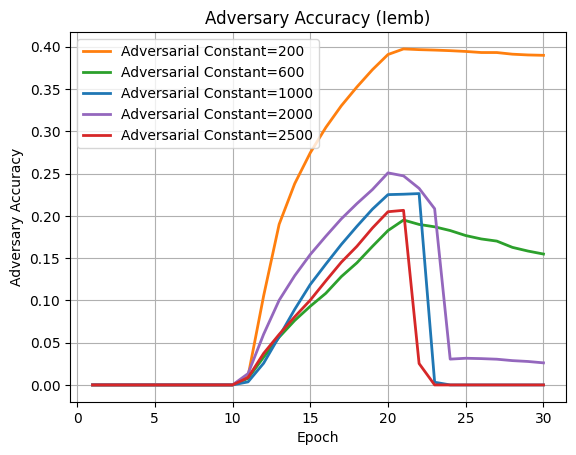

In [55]:
plotline_save_as_pdf2(title='Adversary Accuracy (Iemb)',axis_x1 = range(1,30 + 1), axis_x2 = range(1,30 + 1), xlabel = 'Epoch', axis_y1 = list_acc_Adv200, axis_y2 = list_acc_Adv600 , axis_y3 = list_acc_Adv1000, axis_y4 = list_acc_Adv2000, axis_y5 = list_acc_Adv2500, ylabel ='Adversary Accuracy', linewidth=2, plot_file = './unfairBPR_plots/Iemb_adversary_accuracy.pdf',legendy1='Adversarial Constant=200',legendy2='Adversarial Constant=600',legendy3='Adversarial Constant=1000',legendy4='Adversarial Constant=2000',legendy5='Adversarial Constant=2500')
 

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
from colour import Color

def savepdf_barplot_color_gradient2(ymin = 0.5, ymax = 0.7, whis = 5, start_color='pink',end_color='blue',num_color=5, title='',axis_x = None, xlabel = '', axis_y1 = None, ylabel ='', plot_file = ''):
    
    fig = plt.figure()
    gs = fig.add_gridspec(1, 2, hspace=0, wspace=0)
    (ax1, ax2) = gs.subplots(sharex='col', sharey='row')
    
    red = Color(start_color)
    colors = list(red.range_to(Color(end_color), num_color))
    colors = [color.rgb for color in colors]
    
    X_axis = np.arange(len(axis_x))
    ax1.bar(X_axis, axis_y1, color=colors)
    ax1.hlines(y=axis_y1[0], xmin = 0, xmax = len(axis_x)-1, colors='black', linestyles='--', lw=1)
    
    plt.sca(ax1)
    plt.xticks(X_axis, axis_x, rotation =50)
    #plt.xlabel(xlabel)
    #fig.suptitle(title)
    plt.ylabel(ylabel, fontsize=18)
    plt.rcParams.update({'font.size': 13}) 
    plt.grid()
    
    plt.sca(ax2)
    ax2.boxplot(axis_y1, whis = whis)
    ax1.set_ylim(ymin, ymax)
    
    plt.tight_layout()
    plt.savefig(plot_file)

def savepdf_barplot_color_gradient(ymin = 0.5, ymax = 0.7, start_color='orange',end_color='yellow',num_color=3, title='',axis_x = None, xlabel = '', axis_y1 = None, axis_y2 = None, axis_y3 = None, ylabel ='',barwidth = 0.3, plot_file = '',legendy1 = '',legendy2 = '',legendy3 = ''):
    
    fig, ax1 = plt.subplots()
#     gs = fig.add_gridspec(1, 2, hspace=0, wspace=0)
#     (ax1, ax2) = gs.subplots(sharex='col', sharey='row')
    #fig.suptitle('Sharing x per column, y per row')
    
#     ax1.plot(x + 1, -y, 'tab:green')
#     ax2.plot(x + 2, -y**2, 'tab:red')

#     for ax in fig.get_axes():
#         ax.label_outer()
    
    red = Color(start_color)
    colors = list(red.range_to(Color(end_color), num_color))
    colors = [color.rgb for color in colors]
    
    X_axis = np.arange(len(axis_x))
    #ax1.bar(X_axis, axis_y1, color=colors)
    ax1.bar(2*X_axis - barwidth, axis_y1, width =barwidth, color=colors[num_color-num_color], label = legendy1)
    ax1.bar(2*X_axis + 0, axis_y2, width = barwidth, color=colors[num_color-2],label = legendy2)
    ax1.bar(2*X_axis + barwidth, axis_y3, width = barwidth, color=colors[num_color-1],label = legendy3)
    
    ax1.set_ylim(ymin, ymax)

    #plt.xlabel(xlabel, fontsize=22)
    plt.ylabel(ylabel, fontsize=18)
    #fig.suptitle(title)
    plt.grid()
    plt.legend(fontsize=12) 
    plt.rcParams.update({'font.size': 12})   
    #ax2 = ax1.twinx()
    #ax1.boxplot([[axis_y1[0],axis_y2[0],axis_y3[0]],[axis_y1[1],axis_y2[1],axis_y3[1]],[axis_y1[2],axis_y2[2],axis_y3[2]]], positions=[2*X_axis[0], 2*X_axis[1] , 2*X_axis[2] ])
    ax1.boxplot([[axis_y1[0],axis_y2[0],axis_y3[0]],[axis_y1[1],axis_y2[1],axis_y3[1]],[axis_y1[2],axis_y2[2],axis_y3[2]],[axis_y1[3],axis_y2[3],axis_y3[3]],[axis_y1[4],axis_y2[4],axis_y3[4]]], positions=[2*X_axis[0], 2*X_axis[1] , 2*X_axis[2], 2*X_axis[3], 2*X_axis[4]])
   
    #ax1.set_xticklabels(axis_x)
    plt.xticks(2*X_axis, axis_x)
    
    plt.tight_layout()
    plt.savefig(plot_file)
    
    
    
    
def savepdf_barplot_color_gradient3(ymin = 0.5, ymax = 0.7, title='', axis_x = None, xlabel = '', axis_y = None, ylabel ='',barwidth = 0.3, plot_file = ''):
    
    fig, ax1 = plt.subplots()
    
    X_axis = np.arange(len(axis_x))
    #ax1.bar(X_axis, axis_y1, color=colors)
    #ax1.bar(2*X_axis - barwidth, axis_y1, width =barwidth, color=colors[num_color-num_color], label = legendy1)
    ax1.bar(2*X_axis + 0, axis_y, width = barwidth, color='orange')
    #ax1.bar(2*X_axis + barwidth, axis_y3, width = barwidth, color=colors[num_color-1],label = legendy3)
    
    ax1.set_ylim(ymin, ymax)

    plt.ylabel(ylabel, fontsize=18)
    #fig.suptitle(title)
    plt.grid()
    plt.legend(fontsize=12) 
    plt.rcParams.update({'font.size': 12})   
    plt.xticks(2*X_axis, axis_x)
    
    plt.tight_layout()
    plt.savefig(plot_file)
    
def plotline_save_as_pdf(title='',axis_x = None, xlabel = '', axis_y1 = None, axis_y2 = None , axis_y3 = None, axis_y4 = None,axis_y5 = None, ylabel ='', linewidth=3, plot_file = '',legendy1='',legendy2='',legendy3='',legendy4='',legendy5=''):
    if axis_y1 is not None:
        plt.plot(axis_x, axis_y1, color='orange', linewidth = linewidth, label = legendy1)
    if axis_y2 is not None:
        plt.plot(axis_x, axis_y2, 'g', linewidth = linewidth, label = legendy2)
    if axis_y3 is not None:
        plt.plot(axis_x, axis_y3, 'b', linewidth = linewidth, label = legendy3)
    if axis_y4 is not None:
        plt.plot(axis_x, axis_y4, 'black', linewidth = linewidth, label = legendy4)
    if axis_y5 is not None:
        plt.plot(axis_x, axis_y5, 'red', linewidth = linewidth, label = legendy5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.savefig(plot_file)

def plotline_save_as_pdf2(title='',axis_x1 = None,axis_x2 = None, xlabel = '', axis_y1 = None, axis_y2 = None , axis_y3 = None, axis_y4 = None,axis_y5 = None, ylabel ='', linewidth=3, plot_file = '',legendy1='',legendy2='',legendy3='',legendy4='',legendy5=''):
    if axis_y1 is not None:
        plt.plot(axis_x1, axis_y1, color='tab:orange', linewidth = linewidth, label = legendy1)
    if axis_y2 is not None:
        plt.plot(axis_x2, axis_y2, color='tab:green', linewidth = linewidth, label = legendy2)
    if axis_y3 is not None:
        plt.plot(axis_x2, axis_y3, color='tab:blue', linewidth = linewidth, label = legendy3)
    if axis_y4 is not None:
        plt.plot(axis_x2, axis_y4, color='tab:purple', linewidth = linewidth, label = legendy4)
    if axis_y5 is not None:
        plt.plot(axis_x2, axis_y5, color='tab:red', linewidth = linewidth, label = legendy5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.savefig(plot_file)


In [31]:
# auc_constiemfairadvbpr = []

# auc_per_type_constiemfairadvbpr = []

# for rec in list_recom_constiemfairadvbpr:
#     [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

#     [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
#     auc = utility.auc_per_user(rec, test_df, train_df)
#     auc_constiemfairadvbpr.append(auc)

#     auc_per_type_constiemfairadvbpr.append(auc_per_user_type)




In [33]:
auc_plot_unfairbpr=[]
auc_plot_constiemfairbpr=[]
auc_plot_fairadvbpr=[]
auc_plot_iemfairadvbpr=[]
auc_plot_uemfairadvbpr=[]

precision_plot_unfairbpr=[]
precision_plot_constiemfairbpr=[]
precision_plot_fairadvbpr=[]
precision_plot_iemfairadvbpr=[]
precision_plot_uemfairadvbpr=[]

recall_plot_unfairbpr=[]
recall_plot_constiemfairbpr=[]
recall_plot_fairadvbpr=[]
recall_plot_iemfairadvbpr=[]
recall_plot_uemfairadvbpr=[]

ndcg_plot_unfairbpr=[]
ndcg_plot_constiemfairbpr=[]
ndcg_plot_fairadvbpr=[]
ndcg_plot_iemfairadvbpr=[]
ndcg_plot_uemfairadvbpr=[]

precision_perUserType_plot_unfairbpr=[]
precision_perUserType_plot_constiemfairbpr=[]
precision_perUserType_plot_fairadvbpr=[]
precision_perUserType_plot_iemfairadvbpr=[]
precision_perUserType_plot_uemfairadvbpr=[]

recall_perUserType_plot_unfairbpr=[]
recall_perUserType_plot_constiemfairbpr=[]
recall_perUserType_plot_fairadvbpr=[]
recall_perUserType_plot_iemfairadvbpr=[]
recall_perUserType_plot_uemfairadvbpr=[]

ndcg_perUserType_plot_unfairbpr=[]
ndcg_perUserType_plot_constiemfairbpr=[]
ndcg_perUserType_plot_fairadvbpr=[]
ndcg_perUserType_plot_iemfairadvbpr=[]
ndcg_perUserType_plot_uemfairadvbpr=[]

auc_perUserType_plot_unfairbpr=[]
auc_perUserType_plot_constiemfairbpr=[]
auc_perUserType_plot_fairadvbpr=[]
auc_perUserType_plot_iemfairadvbpr=[]
auc_perUserType_plot_uemfairadvbpr=[]

for rec in list_recom_unfairbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_unfairbpr.append(auc)
    precision_plot_unfairbpr.append(precision)
    recall_plot_unfairbpr.append(recall)
    ndcg_plot_unfairbpr.append(ndcg)
    
    precision_perUserType_plot_unfairbpr.append(precision_per_user_type)
    recall_perUserType_plot_unfairbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_unfairbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_unfairbpr.append(auc_per_user_type)
    
# for rec in list_recom_constiemfairbpr:
#     [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

#     [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
#     auc = utility.auc_per_user(rec, test_df, train_df)
#     auc_plot_constiemfairbpr.append(auc)
#     precision_plot_constiemfairbpr.append(precision)
#     recall_plot_constiemfairbpr.append(recall)
#     ndcg_plot_constiemfairbpr.append(ndcg)
    
#     precision_perUserType_plot_constiemfairbpr.append(precision_per_user_type)
#     recall_perUserType_plot_constiemfairbpr.append(recall_per_user_type)
#     ndcg_perUserType_plot_constiemfairbpr.append(ndcg_per_user_type)
#     auc_perUserType_plot_constiemfairbpr.append(auc_per_user_type)

for rec in list_recom_fairadvbpr:
    [precision, recall, f_score, ndcg] = utility.test_model_all(rec, test_df, train_df)

    [precision_per_user_type, recall_per_user_type, ndcg_per_user_type, auc_per_user_type] = utility.test_model_per_user_type(rec, test_df, train_df, user_type_list, key_type)
    auc = utility.auc_per_user(rec, test_df, train_df)
    auc_plot_fairadvbpr.append(auc)
    precision_plot_fairadvbpr.append(precision)
    recall_plot_fairadvbpr.append(recall)
    ndcg_plot_fairadvbpr.append(ndcg)
    
    precision_perUserType_plot_fairadvbpr.append(precision_per_user_type)
    recall_perUserType_plot_fairadvbpr.append(recall_per_user_type)
    ndcg_perUserType_plot_fairadvbpr.append(ndcg_per_user_type)
    auc_perUserType_plot_fairadvbpr.append(auc_per_user_type)

    


precision_1	[0.2937434],	||	 precision_5	[0.2072110],	||	 precision_10	[0.1810180],	||	 precision_15	[0.1655002]
recall_1   	[0.0171629],	||	 recall_5   	[0.0541149],	||	 recall_10   	[0.0879875],	||	 recall_15   	[0.1191954]
f_measure_1	[0.0324310],	||	 f_measure_5	[0.0858177],	||	 f_measure_10	[0.1184164],	||	 f_measure_15	[0.1385821]
ndcg_1     	[0.2937434],	||	 ndcg_5     	[0.2246335],	||	 ndcg_10     	[0.2089777],	||	 ndcg_15     	[0.2051595]
Metrics for user type	 M
precision_1	[0.3119403],	||	 precision_5	[0.2205970],	||	 precision_10	[0.1964179],	||	 precision_15	[0.1791045]
recall_1	[0.0174564],	||	 recall_5	[0.0552194],	||	 recall_10	[0.0920322],	||	 recall_15	[0.1254479]
ndcg_1	[0.3119403],	||	 ndcg_5	[0.2386179],	||	 ndcg_10	[0.2239356],	||	 ndcg_15	[0.2191485]
AUC per user type	[0.7931987]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1743590],	||	 precision_10	[0.1432234],	||	 precision_15	[0.1321123]
recall_1	[0.0164427],	||	 recall_5	[0.0514039],	

precision_1	[0.2895016],	||	 precision_5	[0.2131495],	||	 precision_10	[0.1780488],	||	 precision_15	[0.1635207]
recall_1   	[0.0159184],	||	 recall_5   	[0.0498731],	||	 recall_10   	[0.0798503],	||	 recall_15   	[0.1126169]
f_measure_1	[0.0301774],	||	 f_measure_5	[0.0808328],	||	 f_measure_10	[0.1102544],	||	 f_measure_15	[0.1333769]
ndcg_1     	[0.2895016],	||	 ndcg_5     	[0.2304933],	||	 ndcg_10     	[0.2065599],	||	 ndcg_15     	[0.2021949]
Metrics for user type	 M
precision_1	[0.3059701],	||	 precision_5	[0.2304478],	||	 precision_10	[0.1916418],	||	 precision_15	[0.1766169]
recall_1	[0.0166357],	||	 recall_5	[0.0532515],	||	 recall_10	[0.0849772],	||	 recall_15	[0.1191660]
ndcg_1	[0.3059701],	||	 ndcg_5	[0.2481735],	||	 ndcg_10	[0.2220730],	||	 ndcg_15	[0.2173525]
AUC per user type	[0.8096018]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1706960],	||	 precision_10	[0.1446886],	||	 precision_15	[0.1313797]
recall_1	[0.0141579],	||	 recall_5	[0.0415819],	

precision_1	[0.3244963],	||	 precision_5	[0.2146341],	||	 precision_10	[0.1851538],	||	 precision_15	[0.1671969]
recall_1   	[0.0174588],	||	 recall_5   	[0.0494542],	||	 recall_10   	[0.0852946],	||	 recall_15   	[0.1145860]
f_measure_1	[0.0331349],	||	 f_measure_5	[0.0803864],	||	 f_measure_10	[0.1167884],	||	 f_measure_15	[0.1359801]
ndcg_1     	[0.3244963],	||	 ndcg_5     	[0.2365191],	||	 ndcg_10     	[0.2153195],	||	 ndcg_15     	[0.2078346]
Metrics for user type	 M
precision_1	[0.3447761],	||	 precision_5	[0.2325373],	||	 precision_10	[0.1991045],	||	 precision_15	[0.1795025]
recall_1	[0.0184854],	||	 recall_5	[0.0525005],	||	 recall_10	[0.0902171],	||	 recall_15	[0.1217114]
ndcg_1	[0.3447761],	||	 ndcg_5	[0.2550831],	||	 ndcg_10	[0.2313291],	||	 ndcg_15	[0.2229171]
AUC per user type	[0.8133875]
Metrics for user type	 F
precision_1	[0.2747253],	||	 precision_5	[0.1706960],	||	 precision_10	[0.1509158],	||	 precision_15	[0.1369963]
recall_1	[0.0149394],	||	 recall_5	[0.0419778],	

precision_1	[0.3234358],	||	 precision_5	[0.2163309],	||	 precision_10	[0.1855779],	||	 precision_15	[0.1708731]
recall_1   	[0.0181261],	||	 recall_5   	[0.0516607],	||	 recall_10   	[0.0876930],	||	 recall_15   	[0.1207315]
f_measure_1	[0.0343284],	||	 f_measure_5	[0.0834041],	||	 f_measure_10	[0.1191044],	||	 f_measure_15	[0.1414914]
ndcg_1     	[0.3234358],	||	 ndcg_5     	[0.2399041],	||	 ndcg_10     	[0.2181099],	||	 ndcg_15     	[0.2135664]
Metrics for user type	 M
precision_1	[0.3417910],	||	 precision_5	[0.2322388],	||	 precision_10	[0.2010448],	||	 precision_15	[0.1850746]
recall_1	[0.0185014],	||	 recall_5	[0.0542465],	||	 recall_10	[0.0937135],	||	 recall_15	[0.1277823]
ndcg_1	[0.3417910],	||	 ndcg_5	[0.2564355],	||	 ndcg_10	[0.2343690],	||	 ndcg_15	[0.2289918]
AUC per user type	[0.8182606]
Metrics for user type	 F
precision_1	[0.2783883],	||	 precision_5	[0.1772894],	||	 precision_10	[0.1476190],	||	 precision_15	[0.1360195]
recall_1	[0.0172051],	||	 recall_5	[0.0453145],	

precision_1	[0.3032874],	||	 precision_5	[0.2150583],	||	 precision_10	[0.1887593],	||	 precision_15	[0.1705903]
recall_1   	[0.0173136],	||	 recall_5   	[0.0540541],	||	 recall_10   	[0.0918930],	||	 recall_15   	[0.1235535]
f_measure_1	[0.0327572],	||	 f_measure_5	[0.0863935],	||	 f_measure_10	[0.1236096],	||	 f_measure_15	[0.1433110]
ndcg_1     	[0.3032874],	||	 ndcg_5     	[0.2333303],	||	 ndcg_10     	[0.2174502],	||	 ndcg_15     	[0.2117315]
Metrics for user type	 M
precision_1	[0.3208955],	||	 precision_5	[0.2298507],	||	 precision_10	[0.2011940],	||	 precision_15	[0.1839801]
recall_1	[0.0179456],	||	 recall_5	[0.0564478],	||	 recall_10	[0.0952154],	||	 recall_15	[0.1298398]
ndcg_1	[0.3208955],	||	 ndcg_5	[0.2490481],	||	 ndcg_10	[0.2312307],	||	 ndcg_15	[0.2261402]
AUC per user type	[0.8146753]
Metrics for user type	 F
precision_1	[0.2600733],	||	 precision_5	[0.1787546],	||	 precision_10	[0.1582418],	||	 precision_15	[0.1377289]
recall_1	[0.0157625],	||	 recall_5	[0.0481795],	

precision_1	[0.3202545],	||	 precision_5	[0.2226935],	||	 precision_10	[0.1777306],	||	 precision_15	[0.1638035]
recall_1   	[0.0174880],	||	 recall_5   	[0.0525700],	||	 recall_10   	[0.0801720],	||	 recall_15   	[0.1082339]
f_measure_1	[0.0331650],	||	 f_measure_5	[0.0850603],	||	 f_measure_10	[0.1104992],	||	 f_measure_15	[0.1303431]
ndcg_1     	[0.3202545],	||	 ndcg_5     	[0.2436104],	||	 ndcg_10     	[0.2119454],	||	 ndcg_15     	[0.2053669]
Metrics for user type	 M
precision_1	[0.3402985],	||	 precision_5	[0.2400000],	||	 precision_10	[0.1937313],	||	 precision_15	[0.1781095]
recall_1	[0.0180304],	||	 recall_5	[0.0558684],	||	 recall_10	[0.0858533],	||	 recall_15	[0.1159301]
ndcg_1	[0.3402985],	||	 ndcg_5	[0.2613732],	||	 ndcg_10	[0.2288184],	||	 ndcg_15	[0.2212996]
AUC per user type	[0.8174110]
Metrics for user type	 F
precision_1	[0.2710623],	||	 precision_5	[0.1802198],	||	 precision_10	[0.1384615],	||	 precision_15	[0.1286935]
recall_1	[0.0161567],	||	 recall_5	[0.0444749],	

precision_1	[0.2884411],	||	 precision_5	[0.1972428],	||	 precision_10	[0.1597031],	||	 precision_15	[0.1469777]
recall_1   	[0.0164439],	||	 recall_5   	[0.0480044],	||	 recall_10   	[0.0772186],	||	 recall_15   	[0.1075986]
f_measure_1	[0.0311140],	||	 f_measure_5	[0.0772161],	||	 f_measure_10	[0.1041023],	||	 f_measure_15	[0.1242425]
ndcg_1     	[0.2884411],	||	 ndcg_5     	[0.2157344],	||	 ndcg_10     	[0.1900587],	||	 ndcg_15     	[0.1863448]
Metrics for user type	 M
precision_1	[0.3059701],	||	 precision_5	[0.2131343],	||	 precision_10	[0.1716418],	||	 precision_15	[0.1570149]
recall_1	[0.0170341],	||	 recall_5	[0.0513354],	||	 recall_10	[0.0800068],	||	 recall_15	[0.1113505]
ndcg_1	[0.3059701],	||	 ndcg_5	[0.2326432],	||	 ndcg_10	[0.2039195],	||	 ndcg_15	[0.1984437]
AUC per user type	[0.8268590]
Metrics for user type	 F
precision_1	[0.2454212],	||	 precision_5	[0.1582418],	||	 precision_10	[0.1304029],	||	 precision_15	[0.1223443]
recall_1	[0.0149954],	||	 recall_5	[0.0398293],	

precision_1	[0.2778367],	||	 precision_5	[0.2008484],	||	 precision_10	[0.1770944],	||	 precision_15	[0.1666313]
recall_1   	[0.0167939],	||	 recall_5   	[0.0556653],	||	 recall_10   	[0.0940087],	||	 recall_15   	[0.1306971]
f_measure_1	[0.0316733],	||	 f_measure_5	[0.0871711],	||	 f_measure_10	[0.1228198],	||	 f_measure_15	[0.1464928]
ndcg_1     	[0.2778367],	||	 ndcg_5     	[0.2150621],	||	 ndcg_10     	[0.2038587],	||	 ndcg_15     	[0.2053882]
Metrics for user type	 M
precision_1	[0.2895522],	||	 precision_5	[0.2116418],	||	 precision_10	[0.1882090],	||	 precision_15	[0.1787065]
recall_1	[0.0165959],	||	 recall_5	[0.0571032],	||	 recall_10	[0.0967796],	||	 recall_15	[0.1354277]
ndcg_1	[0.2895522],	||	 ndcg_5	[0.2257836],	||	 ndcg_10	[0.2145712],	||	 ndcg_15	[0.2166583]
AUC per user type	[0.8303199]
Metrics for user type	 F
precision_1	[0.2490842],	||	 precision_5	[0.1743590],	||	 precision_10	[0.1498168],	||	 precision_15	[0.1369963]
recall_1	[0.0172797],	||	 recall_5	[0.0521366],	

precision_1	[0.2725345],	||	 precision_5	[0.2012725],	||	 precision_10	[0.1805938],	||	 precision_15	[0.1654295]
recall_1   	[0.0145068],	||	 recall_5   	[0.0482621],	||	 recall_10   	[0.0855323],	||	 recall_15   	[0.1178624]
f_measure_1	[0.0275472],	||	 f_measure_5	[0.0778556],	||	 f_measure_10	[0.1160849],	||	 f_measure_15	[0.1376525]
ndcg_1     	[0.2725345],	||	 ndcg_5     	[0.2174298],	||	 ndcg_10     	[0.2046161],	||	 ndcg_15     	[0.2008367]
Metrics for user type	 M
precision_1	[0.2880597],	||	 precision_5	[0.2173134],	||	 precision_10	[0.1955224],	||	 precision_15	[0.1790050]
recall_1	[0.0149603],	||	 recall_5	[0.0506111],	||	 recall_10	[0.0908552],	||	 recall_15	[0.1247741]
ndcg_1	[0.2880597],	||	 ndcg_5	[0.2339277],	||	 ndcg_10	[0.2205916],	||	 ndcg_15	[0.2160111]
AUC per user type	[0.8316403]
Metrics for user type	 F
precision_1	[0.2344322],	||	 precision_5	[0.1619048],	||	 precision_10	[0.1439560],	||	 precision_15	[0.1321123]
recall_1	[0.0133938],	||	 recall_5	[0.0424971],	

In [ ]:
#plotline_save_as_pdf2(title='AUC On Testing',axis_x1 = range(1, train_epoch + train_epoch_a + train_epoch_all + 1), axis_x2 = range(1,train_epoch + train_epoch_a + train_epoch_all+1), xlabel = 'Epoch', axis_y1 = auc_plot_unfairbpr, axis_y2 = auc_plot_constiemfairbpr , axis_y3 = auc_plot_constiemfairbpr,axis_y4 = auc_plot_constiemfairbpr,axis_y5 = auc_plot_constiemfairbpr, ylabel ='AUC', linewidth=2, plot_file = './unfairBPR_plots/auc_all_methods.pdf',legendy1='UnfairBPR',legendy2='CFairAdvBPR',legendy3='fairAdvBPR',legendy4='iemfairadv',legendy5='uemfairadv')
 

In [ ]:
savepdf_barplot_color_gradient(ymin = 0.7, ymax = 0.92, start_color='purple',end_color='orange',num_color=3, title='AUC per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [auc_plot_unfairbpr[-1],auc_plot_constiemfairbpr[-1],auc_plot_fairadvbpr[-1] ,auc_plot_constiemfairbpr[-1], auc_plot_constiemfairbpr[-1]], axis_y2 = [auc_perUserType_plot_unfairbpr[-1]['M'],auc_perUserType_plot_constiemfairbpr[-1]['M'],auc_perUserType_plot_fairadvbpr[-1]['M'],auc_perUserType_plot_constiemfairbpr[-1]['M'],auc_perUserType_plot_constiemfairbpr[-1]['M']], axis_y3 = [auc_perUserType_plot_unfairbpr[-1]['F'],auc_perUserType_plot_constiemfairbpr[-1]['F'],auc_perUserType_plot_fairadvbpr[-1]['F'],auc_perUserType_plot_constiemfairbpr[-1]['F'],auc_perUserType_plot_constiemfairbpr[-1]['F']], ylabel ='AUC',barwidth = 0.3, plot_file = './unfairBPR_plots/auc_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 

In [ ]:
savepdf_barplot_color_gradient(ymin = 0, ymax = 0.4, start_color='purple',end_color='orange',num_color=3, title='Precision per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [precision_plot_unfairbpr[-1][1], precision_plot_constiemfairbpr[-1][2],precision_plot_fairadvbpr[-1][1] ,precision_plot_constiemfairbpr[-1][1], precision_plot_constiemfairbpr[-1][1]], axis_y2 = [precision_perUserType_plot_unfairbpr[-1]['M'][0].tolist()[1],precision_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[2],precision_perUserType_plot_fairadvbpr[-1]['M'][0].tolist()[1],precision_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[1],precision_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[1]], axis_y3 = [precision_perUserType_plot_unfairbpr[-1]['F'][0].tolist()[1], precision_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[1],precision_perUserType_plot_fairadvbpr[-1]['F'][0].tolist()[1],precision_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[1],precision_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[1]], ylabel ='Precision',barwidth = 0.3, plot_file = './unfairBPR_plots/precision_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 

In [ ]:
savepdf_barplot_color_gradient(ymin = 0.1, ymax = 0.4, start_color='purple',end_color='orange',num_color=3, title='Precision per User Type on Testing (Movielens)',axis_x = ['UnfairBPR','CFairAdvBPR','fairAdvBPR','iemFairAdv','uemFairAdv'], xlabel = '', axis_y1 = [ndcg_plot_unfairbpr[-1][1], ndcg_plot_constiemfairbpr[-1][1],ndcg_plot_fairadvbpr[-1][1] ,ndcg_plot_constiemfairbpr[-1][1], ndcg_plot_constiemfairbpr[-1][1]], axis_y2 = [ndcg_perUserType_plot_unfairbpr[-1]['M'][0].tolist()[1],ndcg_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[2],ndcg_perUserType_plot_fairadvbpr[-1]['M'][0].tolist()[1],ndcg_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[1],ndcg_perUserType_plot_constiemfairbpr[-1]['M'][0].tolist()[1]], axis_y3 = [ndcg_perUserType_plot_unfairbpr[-1]['F'][0].tolist()[1], ndcg_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[0],ndcg_perUserType_plot_fairadvbpr[-1]['F'][0].tolist()[1],ndcg_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[1],ndcg_perUserType_plot_constiemfairbpr[-1]['F'][0].tolist()[1]], ylabel ='NDCG',barwidth = 0.3, plot_file = './unfairBPR_plots/ndcg_per_type.pdf',legendy1='Overall',legendy2='Male',legendy3='Female') 